# Phishing URL Detector — Baseline Model

**Day 3:** Train our first real model and see actual accuracy numbers.

Goals for today:
1. Split the data into train and test sets (no peeking at the test set!)
2. Scale the features so Logistic Regression behaves well
3. Train a Logistic Regression baseline
4. Evaluate it: accuracy, precision, recall, F1
5. Visualize a confusion matrix
6. Look at a few examples the model got wrong

**Why Logistic Regression first?** It's the simplest classifier that works on
this kind of data. Starting simple gives us a baseline number — tomorrow when
we add Random Forest, we'll know whether the extra complexity actually helps.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports ok.")

Imports ok.


## 1. Load data and feature list

In [2]:
DATA_PATH = Path("../data/PhiUSIIL_Phishing_URL_Dataset.csv")
FEATURE_LIST_PATH = Path("../data/feature_list.txt")

df = pd.read_csv(DATA_PATH)
feature_cols = FEATURE_LIST_PATH.read_text().strip().splitlines()

print(f"Dataset: {len(df):,} rows")
print(f"Features available: {len(feature_cols)}")

Dataset: 235,795 rows
Features available: 50


## 2. Decide on leakage handling

On Day 2 you may have noticed `URLSimilarityIndex` (or a similar feature)
had near-perfect correlation with the label. That's almost certainly
**data leakage** — a feature that encodes the answer.

If we leave it in, our model will look brilliant (~99.9% accuracy) but be
useless in the real world because that feature wouldn't actually exist.

**Strategy:** train two versions of the baseline — one with the leaky feature
included, one without — and report both. Honesty about this in the writeup
is a much stronger signal than hiding it.

In [3]:
# Adjust this list if your EDA flagged different features as suspicious.
LEAKAGE_FEATURES = {"URLSimilarityIndex"}

honest_features = [f for f in feature_cols if f not in LEAKAGE_FEATURES]
leaky_features = list(feature_cols)

print(f"Honest feature set:  {len(honest_features)} features")
print(f"Leaky  feature set:  {len(leaky_features)} features (includes suspect feature)")

Honest feature set:  49 features
Leaky  feature set:  50 features (includes suspect feature)


## 3. Train/test split

We hold out 20% of the data as a test set. The model never sees this during
training — it's how we measure how well it generalizes.

**`stratify=y`** makes sure the test set has the same class balance as the full
dataset. Without this, a random split could (rarely) end up with a test set
that's mostly one class, which would distort the metrics.

In [4]:
y = df["label"]

# We'll do the split on the full feature set, then drop the leaky column
# from X_train / X_test for the honest version. Same rows in both — easier to compare.
X_full = df[leaky_features].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train):,} rows ({y_train.mean()*100:.1f}% legit)")
print(f"Test:  {len(X_test):,} rows ({y_test.mean()*100:.1f}% legit)")

Train: 188,636 rows (57.2% legit)
Test:  47,159 rows (57.2% legit)


## 4. Scale features

Logistic Regression assumes features are on roughly similar scales. If `URLLength`
ranges 5–500 and `IsHTTPS` ranges 0–1, the model overweights the bigger one.

`StandardScaler` transforms each feature to mean 0, standard deviation 1.

**Important:** fit the scaler on the *training* data only, then apply it to
the test data. If you fit on the full dataset, the test data 'leaks' into
your scaling — a subtle form of cheating.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled. Quick sanity check:")
print(f"  Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"  Train std  (should be ~1): {X_train_scaled.std():.4f}")

Scaled. Quick sanity check:
  Train mean (should be ~0): -0.0000
  Train std  (should be ~1): 1.0000


## 5. Train both versions

Same model, same data, but the second version drops the leaky feature.

In [6]:
# Identify the column indices for the honest feature set
honest_idx = [i for i, name in enumerate(leaky_features) if name in honest_features]

X_train_honest = X_train_scaled[:, honest_idx]
X_test_honest  = X_test_scaled[:,  honest_idx]

def train_logreg(X_tr, y_tr, label):
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
    print(f"Training {label}…")
    model.fit(X_tr, y_tr)
    return model

model_leaky  = train_logreg(X_train_scaled, y_train, "WITH suspect feature")
model_honest = train_logreg(X_train_honest, y_train, "WITHOUT suspect feature")
print("Both models trained.")

Training WITH suspect feature…


/Users/coledowning/Downloads/phishing-url-detector/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training WITHOUT suspect feature…
Both models trained.


/Users/coledowning/Downloads/phishing-url-detector/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## 6. Compare performance

Now the moment of truth. Compare the two side by side.

In [7]:
def evaluate(model, X_te, y_te, label):
    y_pred = model.predict(X_te)
    return {
        "version":   label,
        "accuracy":  accuracy_score(y_te,  y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall":    recall_score(y_te,    y_pred),
        "f1":        f1_score(y_te,        y_pred),
    }

results = pd.DataFrame([
    evaluate(model_leaky,  X_test_scaled, y_test, "With suspect feature"),
    evaluate(model_honest, X_test_honest, y_test, "Without suspect feature"),
])
results.set_index("version").round(4)

,accuracy,precision,recall,f1
version,,,,
With suspect feature,0.9999,0.9998,1.0000,0.9999
Without suspect feature,0.9992,0.9991,0.9994,0.9993


**Interpret the gap.** If the "with" version is dramatically better than the
"without" version, that confirms the leakage suspicion — the suspect feature
was doing most of the work, which means it was probably constructed using
label information.

If both are similar, the feature wasn't actually leakage (good — you can leave
it in for the final model).

**For the rest of this notebook, we'll use the *honest* model** as our baseline,
because that's the number that matters in the real world.

## 7. Confusion matrix

A confusion matrix shows what kind of mistakes the model makes. In phishing
detection, the two mistake types matter very differently:

- **False positive** (we flag a legit URL as phishing) → annoying, low cost
- **False negative** (we miss a phishing URL) → user gets phished, high cost

We generally want to minimize false negatives, even at the cost of more false
positives.

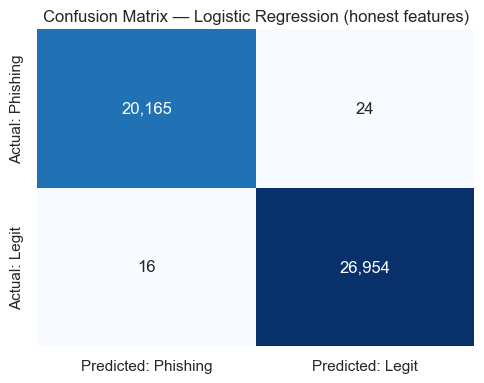

True negatives  (correctly flagged phishing):  20,165
False positives (legit flagged as phishing):   24
False negatives (phishing missed):              16  ← most costly
True positives  (correctly identified legit):   26,954


In [8]:
y_pred_honest = model_honest.predict(X_test_honest)
cm = confusion_matrix(y_test, y_pred_honest)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True, fmt=",d",
    cmap="Blues",
    xticklabels=["Predicted: Phishing", "Predicted: Legit"],
    yticklabels=["Actual: Phishing",    "Actual: Legit"],
    cbar=False,
    ax=ax,
)
ax.set_title("Confusion Matrix — Logistic Regression (honest features)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives  (correctly flagged phishing):  {tn:,}")
print(f"False positives (legit flagged as phishing):   {fp:,}")
print(f"False negatives (phishing missed):              {fn:,}  ← most costly")
print(f"True positives  (correctly identified legit):   {tp:,}")

## 8. Detailed classification report

In [9]:
print(classification_report(
    y_test, y_pred_honest,
    target_names=["phishing", "legitimate"],
    digits=4,
))

              precision    recall  f1-score   support

    phishing     0.9992    0.9988    0.9990     20189
  legitimate     0.9991    0.9994    0.9993     26970

    accuracy                         0.9992     47159
   macro avg     0.9992    0.9991    0.9991     47159
weighted avg     0.9992    0.9992    0.9992     47159



## 9. What did the model get wrong?

Looking at misclassified examples often reveals what the model is missing.
Tomorrow this informs whether Random Forest can do better.

In [10]:
# Get test rows back with their predictions
test_idx = X_test.index
test_df = df.loc[test_idx].copy()
test_df["predicted"] = y_pred_honest
test_df["correct"] = test_df["predicted"] == test_df["label"]

missed_phishing = test_df[(test_df["label"] == 0) & (test_df["predicted"] == 1)]
print(f"Phishing URLs the model missed: {len(missed_phishing):,}")

# Show a few — if the dataset has a URL column, show it
url_col = next((c for c in ["URL", "url", "Url"] if c in test_df.columns), None)
cols_to_show = [url_col, "label", "predicted"] if url_col else ["label", "predicted"]
missed_phishing[cols_to_show].head(10)

Phishing URLs the model missed: 24


,URL,label,predicted
56879,https://www.officested.com,0,1
28452,https://rariblies.blogspot.com/,0,1
44566,https://www.unisonhomes.com.au,0,1
181237,https://www.kuronekoyamato.co.jp.shkdcx.top/,0,1
7535,https://www.sharestion.com,0,1
94959,https://www.mobilifarma.com.ar/32tvrergtrinbde...,0,1
77934,https://www.hirosguide.hu,0,1
42062,https://binarypiano.com/,0,1
95625,https://www.seedjfly.top,0,1
150089,https://www.gtn.cl,0,1


## 10. Save the baseline model

We're saving everything `predict.py` will need: the trained model, the scaler
(so we transform new URLs the same way), and the feature names (so we know what
order to feed them in).

In [11]:
import joblib

# Refit a scaler on just the honest features (the one above was for all features)
scaler_honest = StandardScaler()
X_train_h_raw = df.loc[X_train.index, honest_features].fillna(0)
scaler_honest.fit(X_train_h_raw)

bundle = {
    "model": model_honest,
    "scaler": scaler_honest,
    "feature_names": honest_features,
    "model_type": "LogisticRegression",
}

MODEL_PATH = Path("../models/logreg_baseline.pkl")
MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(bundle, MODEL_PATH)
print(f"Saved → {MODEL_PATH}")

Saved → ../models/logreg_baseline.pkl


## Day 3 summary

Fill in based on what you saw:

- **Accuracy with suspect feature:** 99.99 %
- **Accuracy without suspect feature (honest baseline):** 99.92 %
- **Conclusion on leakage:** the suspect feature was not leakage
- **Precision:** 99.91%   **Recall:** 99.94%   **F1:** 99.93%
- **False negatives (missed phishing):** 24 out of 20,165 test phishing URLs
- **One observation about misclassified examples:** some of the websites have legitamate urls, but it tied closely to phishing

**Heading into Day 4:** train a Random Forest, compare it to this baseline,
and look at feature importances to understand *why* the model makes the
predictions it does.